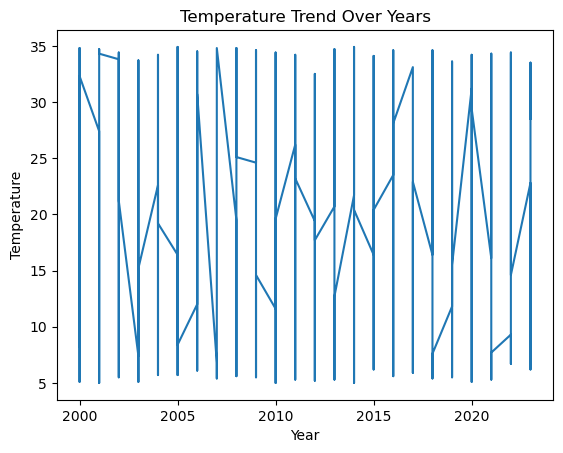

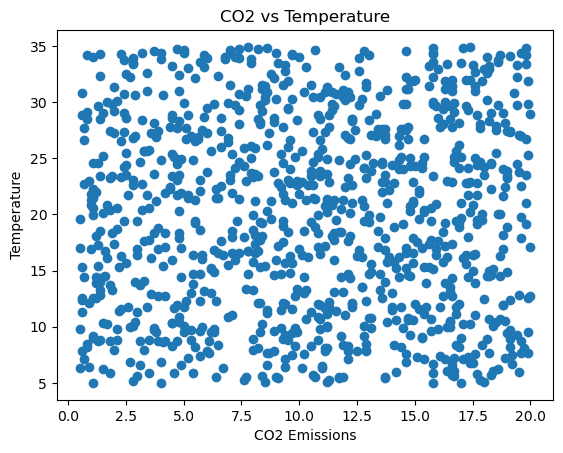

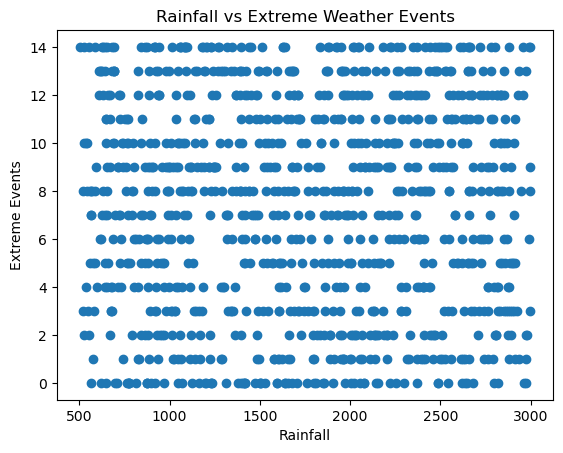

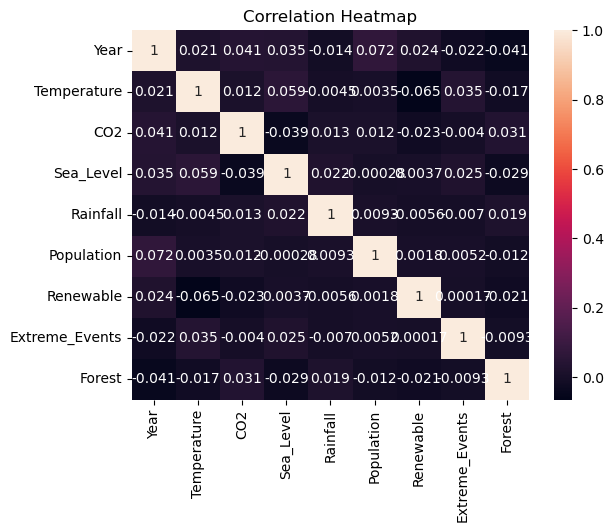


Correlation with Temperature:

Temperature       1.000000
Sea_Level         0.059005
Extreme_Events    0.034951
Year              0.020954
CO2               0.012323
Population        0.003550
Rainfall         -0.004532
Forest           -0.017027
Renewable        -0.065472
Name: Temperature, dtype: float64


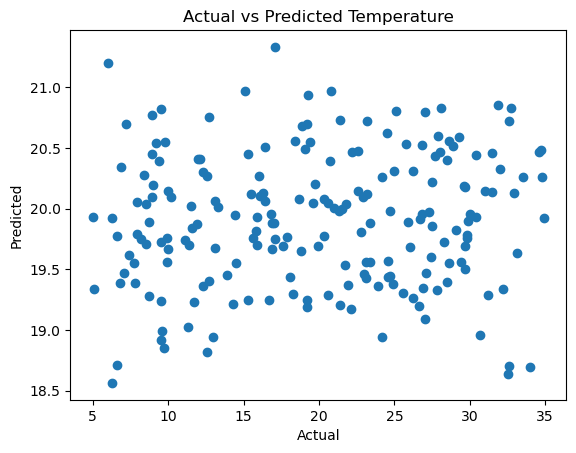


Model R² Score: 0.006192385438243075

Feature Importance:

          Feature    Impact
0             CO2  0.044895
1       Sea_Level  0.398702
2  Extreme_Events  0.030717


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# ---------------------------
# 1. LOAD DATA
# ---------------------------
df = pd.read_csv("disaster.csv")

# ---------------------------
# 2. CLEAN DATA
# ---------------------------
df = df.dropna()
df.columns = df.columns.str.strip()

# Rename columns properly
df.columns = [
    "Year", "Country", "Temperature", "CO2",
    "Sea_Level", "Rainfall", "Population",
    "Renewable", "Extreme_Events", "Forest"
]

# Convert to numeric (except Country)
numeric_cols = df.columns.drop("Country")
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna()

# Sort by year (important for trends)
df = df.sort_values(by="Year")

# ---------------------------
# 3. VISUALIZATIONS
# ---------------------------

# Temperature trend
plt.figure()
plt.plot(df["Year"], df["Temperature"])
plt.title("Temperature Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.savefig("temp_trend.png")
plt.show()

# CO2 vs Temperature
plt.figure()
plt.scatter(df["CO2"], df["Temperature"])
plt.title("CO2 vs Temperature")
plt.xlabel("CO2 Emissions")
plt.ylabel("Temperature")
plt.savefig("co2_vs_temp.png")
plt.show()

# Rainfall vs Extreme Events
plt.figure()
plt.scatter(df["Rainfall"], df["Extreme_Events"])
plt.title("Rainfall vs Extreme Weather Events")
plt.xlabel("Rainfall")
plt.ylabel("Extreme Events")
plt.savefig("rainfall_vs_events.png")
plt.show()

# ---------------------------
# 4. CORRELATION ANALYSIS
# ---------------------------
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

print("\nCorrelation with Temperature:\n")
print(corr["Temperature"].sort_values(ascending=False))

# ---------------------------
# 5. FEATURE SELECTION (IMPROVED)
# ---------------------------
# Using only meaningful features
X = df[["CO2", "Sea_Level", "Extreme_Events"]]
y = df["Temperature"]

# ---------------------------
# 6. TRAIN-TEST SPLIT
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# 7. MODEL TRAINING
# ---------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------
# 8. PREDICTIONS
# ---------------------------
y_pred = model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.savefig("prediction.png")
plt.show()

# ---------------------------
# 9. MODEL PERFORMANCE
# ---------------------------
r2_score = model.score(X_test, y_test)
print("\nModel R² Score:", r2_score)

# ---------------------------
# 10. FEATURE IMPORTANCE
# ---------------------------
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Impact": model.coef_
})

print("\nFeature Importance:\n")
print(coefficients)

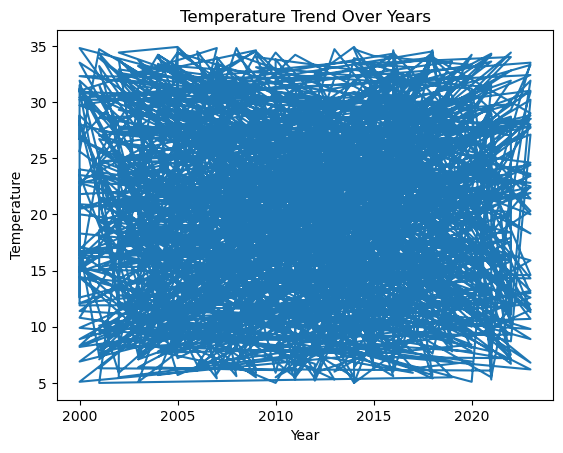

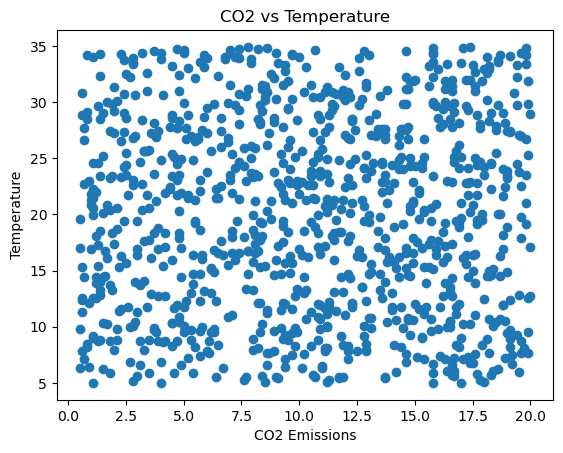

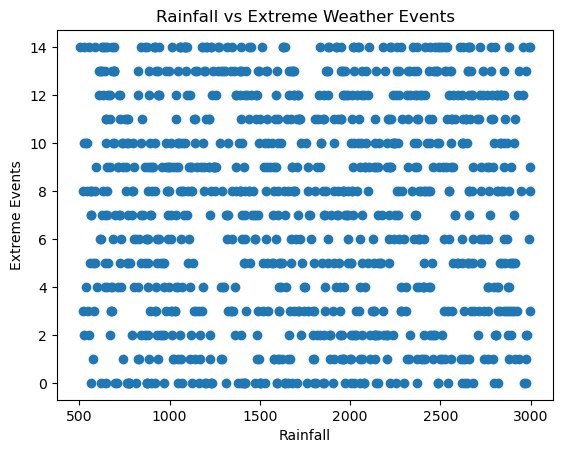

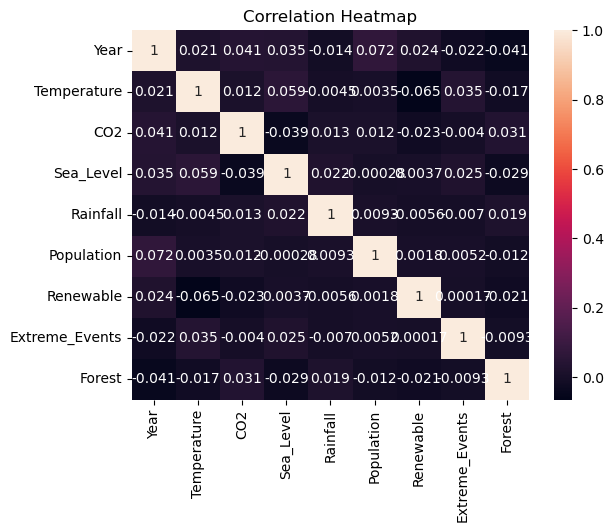

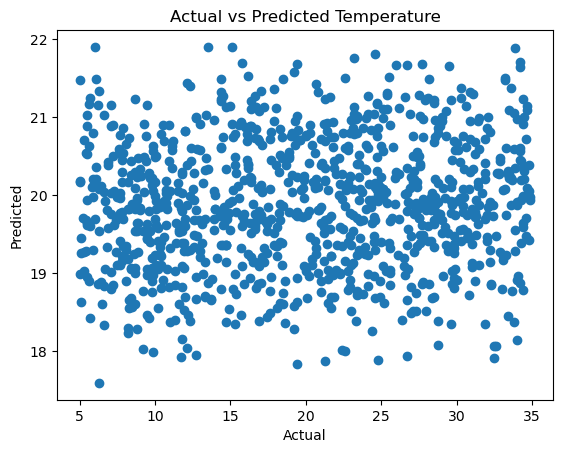

Model R² Score: 0.009420593089134566
          Feature        Impact
0             CO2  2.093869e-02
1       Sea_Level  4.367860e-01
2        Rainfall -7.071385e-05
3      Population  6.702257e-11
4       Renewable -4.331284e-02
5  Extreme_Events  6.440022e-02
6          Forest -8.206258e-03


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

# ---------------------------
# 1. LOAD DATA
# ---------------------------
df = pd.read_csv("disaster.csv")

# ---------------------------
# 2. CLEAN DATA
# ---------------------------
df = df.dropna()
df.columns = df.columns.str.strip()

# Rename columns (IMPORTANT)
df.columns = [
    "Year", "Country", "Temperature", "CO2",
    "Sea_Level", "Rainfall", "Population",
    "Renewable", "Extreme_Events", "Forest"
]

# Convert numeric columns
numeric_cols = df.columns.drop("Country")
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna()

# ---------------------------
# 3. VISUALIZATIONS
# ---------------------------

# Temperature trend
plt.figure()
plt.plot(df["Year"], df["Temperature"])
plt.title("Temperature Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

# CO2 vs Temperature
plt.figure()
plt.scatter(df["CO2"], df["Temperature"])
plt.title("CO2 vs Temperature")
plt.xlabel("CO2 Emissions")
plt.ylabel("Temperature")
plt.show()

# Rainfall vs Extreme Events
plt.figure()
plt.scatter(df["Rainfall"], df["Extreme_Events"])
plt.title("Rainfall vs Extreme Weather Events")
plt.xlabel("Rainfall")
plt.ylabel("Extreme Events")
plt.show()

# ---------------------------
# 4. CORRELATION HEATMAP
# ---------------------------
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# ---------------------------
# 5. MACHINE LEARNING MODEL
# ---------------------------

X = df[[
    "CO2", "Sea_Level", "Rainfall",
    "Population", "Renewable",
    "Extreme_Events", "Forest"
]]

y = df["Temperature"]

model2 = LinearRegression()
model.fit(X, y)

# ---------------------------
# 6. PREDICTIONS
# ---------------------------
predictions = model.predict(X)

plt.figure()
plt.scatter(y, predictions)
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# ---------------------------
# 7. MODEL PERFORMANCE
# ---------------------------
score = model.score(X, y)
print("Model R² Score:", score)

# Feature importance
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Impact": model.coef_
})

print(coefficients)